In [1]:
import json
from urllib.request import urlopen
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm

In [2]:
data_url = "https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790367226-vna-average.json"
averages = json.load(urlopen(data_url))

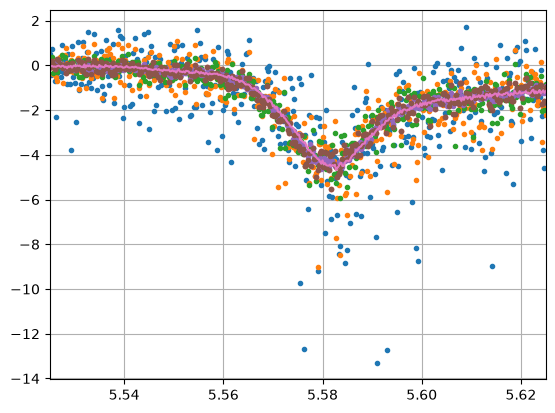

In [5]:
averages['s_db'] = np.array(averages['s_db'])
linear_traces = 10 ** (averages['s_db'] / 20)

linear_average = np.mean(linear_traces[:1], axis=0)
db_average1 = 10 * np.log10(linear_average)
linear_average = np.mean(linear_traces[:3], axis=0)
db_average3 = 10 * np.log10(linear_average)
linear_average = np.mean(linear_traces[:10], axis=0)
db_average10 = 10 * np.log10(linear_average)
linear_average = np.mean(linear_traces[:30], axis=0)
db_average30 = 10 * np.log10(linear_average)
linear_average = np.mean(linear_traces[:100], axis=0)
db_average100 = 10 * np.log10(linear_average)
linear_average = np.mean(linear_traces[:30], axis=0)
db_average300 = 10 * np.log10(linear_average)
linear_average = np.mean(linear_traces[:999], axis=0)
db_average1000 = 10 * np.log10(linear_average)

plt.plot(averages['fghz'],db_average1- db_average1000[0],'.')
plt.plot(averages['fghz'],db_average3 - db_average1000[0],'.')
plt.plot(averages['fghz'],db_average10 - db_average1000[0],'.')
plt.plot(averages['fghz'],db_average30 - db_average1000[0],'.')
plt.plot(averages['fghz'],db_average100 - db_average1000[0],'.')
plt.plot(averages['fghz'],db_average300 - db_average1000[0],'.')
plt.plot(averages['fghz'],db_average1000 - db_average1000[0])

plt.xlim([averages['fghz'][0],averages['fghz'][-1]])
#plt.ylim([])
plt.grid()

(0.0, 1000.0)

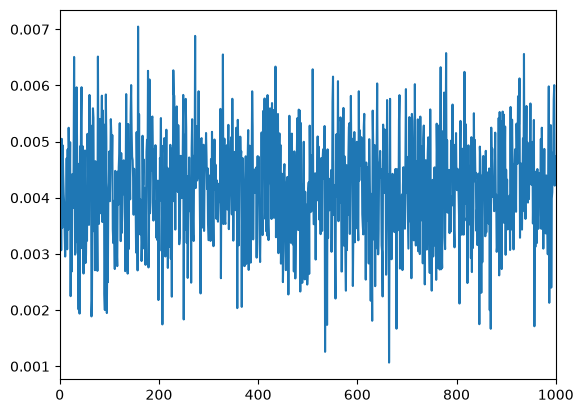

In [6]:
first_point = np.transpose(linear_traces)[0]

plt.plot(first_point)
plt.xlim([0,1000])

(array([ 2.,  0.,  0.,  8.,  8.,  9., 12., 17., 37., 31., 57., 65., 64.,
        62., 73., 77., 94., 94., 67., 61., 42., 45., 25., 21., 12.,  5.,
         5.,  5.,  0.,  2.]),
 array([0.00106604, 0.00126545, 0.00146486, 0.00166427, 0.00186368,
        0.00206309, 0.0022625 , 0.00246191, 0.00266131, 0.00286072,
        0.00306013, 0.00325954, 0.00345895, 0.00365836, 0.00385777,
        0.00405718, 0.00425659, 0.00445599, 0.0046554 , 0.00485481,
        0.00505422, 0.00525363, 0.00545304, 0.00565245, 0.00585186,
        0.00605127, 0.00625067, 0.00645008, 0.00664949, 0.0068489 ,
        0.00704831]),
 <BarContainer object of 30 artists>)

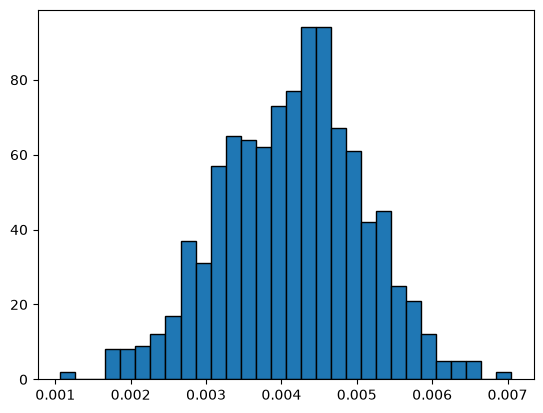

In [7]:
plt.hist(first_point, bins=30, edgecolor="black")


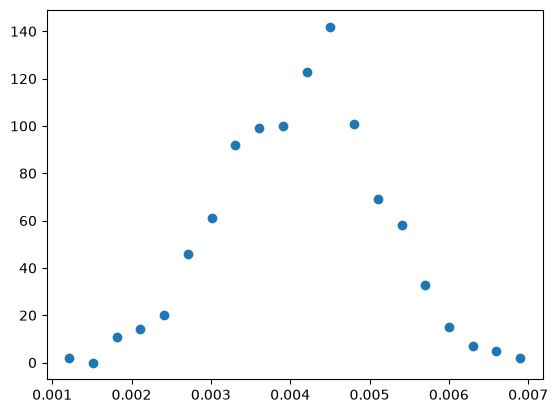

In [8]:
counts, edges = np.histogram(first_point, bins=20)
centers = (edges[:-1] + edges[1:]) / 2

plt.plot(centers, counts, "o")

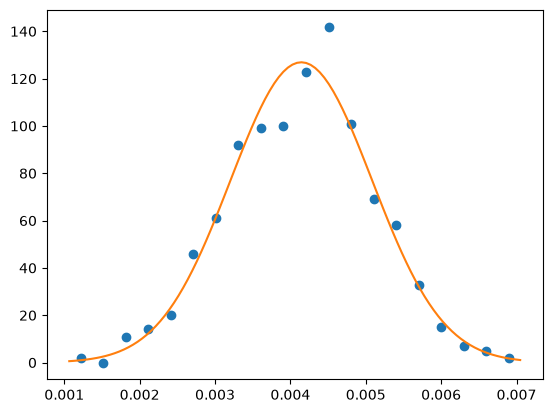

In [9]:
counts, edges = np.histogram(first_point, bins=20)
centers = (edges[:-1] + edges[1:]) / 2
plt.plot(centers, counts, "o")

mu, sigma = norm.fit(first_point)

x = np.linspace(edges[0], edges[-1], 100)
bin_width = edges[1] - edges[0]
y = norm.pdf(x, mu, sigma) * len(first_point) * bin_width

plt.plot(x, y, "-")

In [10]:
mu,sigma

(np.float64(0.004144681091288995), np.float64(0.0009401654340906345))